In [2]:
### Calculating the d18O value of each discharge, so that you can align it to the tracer

[Land sea mask loader]
Elapsed: 0.4036417007446289


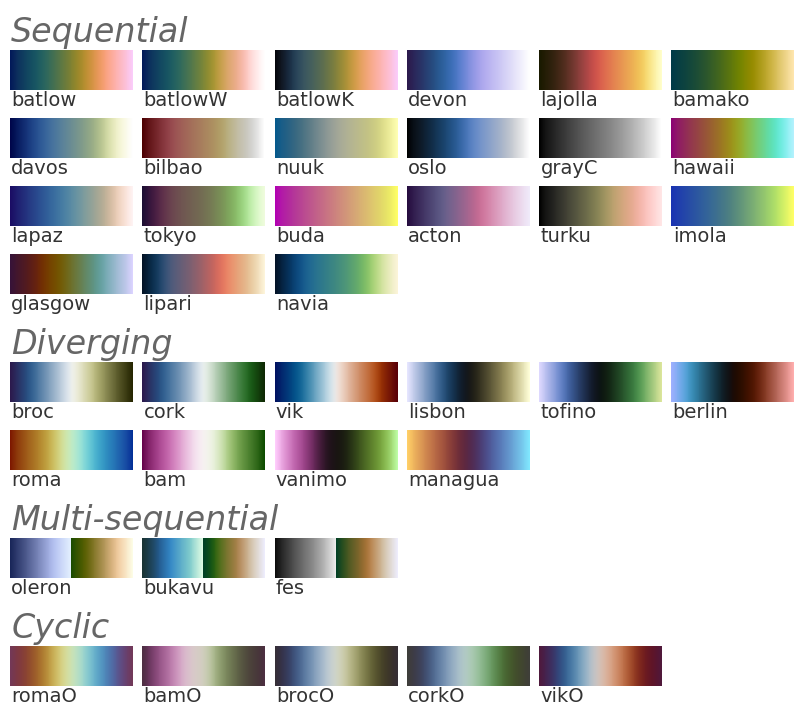

In [1]:
#Define my working directory (important for modules)
import os
os.chdir('/nfs/mary/Users/eelse/scripts/jupyter')

%matplotlib inline
import xarray as xr
import cartopy.feature
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, TwoSlopeNorm, LinearSegmentedColormap, ListedColormap, Normalize
import cmcrameri.cm as cmc

import numpy as np

import mw_protocol.plotting as plotting
import mw_protocol.glac1d_toolbox as tb

import mymodules.myfunc as mf 

import cftime
import regionmask
import geopandas as gpd
import pandas as pd

#landmask
with mf.Timer('Land sea mask loader'):
    data_folder = f"/nfs/annie/eeymr/work/data/publication/ROME2022_paleoceanography_oscillations"
    ds_lsm = xr.open_dataset(f"{data_folder}/lgm_inputs/temev.qrparm.omask.nc")
    lsm = ds_lsm.lsm

from cmcrameri import show_cmaps
show_cmaps()


In [4]:
### Step 1: How much meltwater into each region?

#Regions
ds_dyeregion = xr.open_dataset('myintermediates/dyestuff_modelpaper/dye_regions_norm.nc')
dyen = list(ds_dyeregion.data_vars)

#Regionfluxes
gdf = pd.read_pickle('myintermediates/gdf_regions.pkl') #update this is already the full computation

# Update: with calculations (just for a quick export now)
gdg = pd.read_pickle("myintermediates/regionalmeltdischarge_withd18O.pkl")


In [54]:
gdg.to_csv('myintermediates/region2.csv')
gdg['mean (-35.0) region d18O anomaly 18.2 ka']

0   -0.024235
1   -0.121597
2   -1.752939
3   -7.916263
4   -0.646742
5   -0.186351
6   -0.384894
7   -0.437211
8   -0.332800
Name: mean (-35.0) region d18O anomaly 18.2 ka, dtype: float64

In [5]:
gdf.to_csv('myintermediates/region1.csc')
gdf

,Name,Description,geometry,Region Melt 17.8ka (Sv),Region Melt 18.2 ka (Sv),Region Melt 19.4 ka (Sv),Region Melt 20.7 ka (Sv)
0,Mediterranean,,"POLYGON Z ((26.53000 27.89000 -516.02000, -4.0...",0.000607,0.000392,0.000473,0.000304
1,British,,"POLYGON Z ((-13.00000 63.00000 -5427.06000, 0....",0.000645,0.000543,0.021257,0.018850
2,Fennoscandia,,"POLYGON Z ((60.19000 65.22000 -2865.50000, 5.0...",0.017564,0.009781,0.002862,0.001791
3,Eurasian Arctic,,"POLYGON Z ((9.00000 87.00000 -7001.35000, 9.00...",0.024581,0.065071,0.009473,0.007724
4,American Arctic,,"POLYGON Z ((-95.12000 67.79000 -2027.28000, -1...",0.011424,0.007986,0.009007,0.013253
5,GIS,,"POLYGON Z ((-35.00000 78.04000 -4428.90000, -3...",0.000755,0.000762,0.000756,0.000753
6,N Laurentide,,"POLYGON Z ((-87.58000 66.06000 -1608.02000, -8...",0.003795,0.004675,0.014636,0.011915
7,S Laurentide,,"POLYGON Z ((-53.00000 50.00000 -7695.96000, -9...",0.003525,0.006347,0.009251,0.005931
8,Gulf of Mexico,,"POLYGON Z ((-101.17000 22.06000 1667.96000, -8...",0.009756,0.003613,0.017072,0.006837


In [9]:
# you need to calculate the volume of the surface layer of each grid cell and then mask it to only have the sum of the region. (Then you can calculate the d18O signature at the location).

# A surface volume matrix

lon_dis, lat_dis = ds_dyeregion.longitude.values, ds_dyeregion.latitude.values
lon_dis_b, lat_dis_b = tb.create_coordinate_edges(lon_dis), tb.create_coordinate_edges(lat_dis)

# Create empty array for result
vol = np.empty((len(lat_dis), len(lon_dis)))

# Loop over grid
for i, lat in enumerate(lat_dis):
    for j, lon in enumerate(lon_dis):
        vol[i, j] = mf.cell_volume(lon_dis_b[j],lon_dis_b[j+1],lat_dis_b[i],lat_dis_b[i+1],0,10)

# Create a DataArray
surface_volume = xr.DataArray(
    vol,
    coords={"latitude": lat_dis, "longitude": lon_dis},
    dims=("latitude", "longitude"),
    name="surface_volume",
)

# Add it to your Dataset
ds_dyeregion["surface_volume"] = surface_volume






In [7]:
# Plot of Meltwater d18O discharge by Region

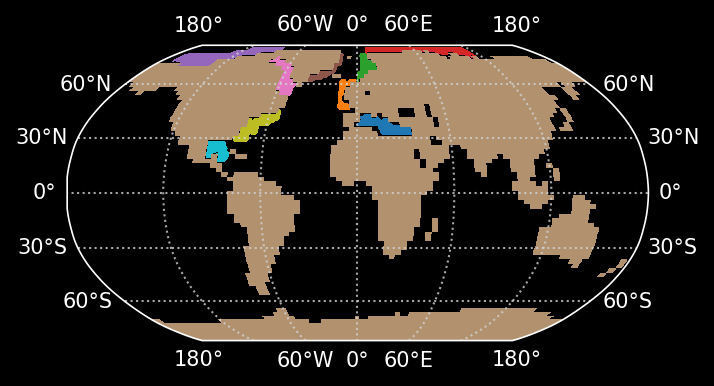

In [10]:
projection_map = ccrs.Robinson()
figMap,axMap = plt.subplots(nrows=1, ncols=1, subplot_kw={'projection':projection_map}, figsize=(5,5))
#axMap = axMap.flatten()
#normDis = Normalize(vmin=0,vmax= 2e-5)
minlev=0
lev = 0.001

plt.style.use("dark_background")
plt.rcParams.update({
    "figure.figsize": (12, 8),        # bigger figure
    "figure.dpi": 150,                # high resolution
    "axes.titlesize": 24,             # title font
    "axes.labelsize": 20,             # axis label font
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
    "lines.linewidth": 3,             # thicker lines
    "lines.markersize": 8,
    "font.family": "sans-serif",
})
#150F2B
#cmap = plt.get_cmap('rainbow')
#cmap.set_under('white')  # Color for values less than vmin
eps = np.spacing(0.0)

colores = {'0':'tab:blue', '1':'tab:orange', '2':'tab:green', '3':'tab:red', '4':'tab:purple', '5':'tab:brown', '6':'tab:pink',
         '7':'tab:olive', '8':'tab:cyan'}


for i,d in enumerate(dyen[1:]):
    axMap.contourf(lon_dis, lat_dis,ds_dyeregion[d].clip(min=eps).isel(t=0,depth=0), transform=ccrs.PlateCarree(), 
                                          levels=[0.1, 1],colors=colores[f'{i}'])

axMap.pcolormesh(lon_dis_b, lat_dis_b,xr.where(lsm==0, np.nan,lsm),
              cmap=ListedColormap(['xkcd:pale brown']), transform=ccrs.PlateCarree(),
              zorder=1,alpha=1)
#axMap.coastlines(alpha=0.2)
#axMap.gridlines()
axMap.gridlines(crs=ccrs.PlateCarree(), linewidth=1, color='lightgray', alpha=0.8, linestyle=':', draw_labels=True)

plt.savefig("MeltDischarge_Regions.png", transparent=True, dpi=300, bbox_inches='tight')




In [14]:
# Boundary conditions for d18O of input meltwater
min_ice_d18O = -40.0 #permil d18O
mean_ice_d18O = -35.0 #permil d18O
max_ice_d18O = -30.0 #permil d18O


gdfm = gdg.melt(id_vars="Name",value_vars=[f"mean ({mean_ice_d18O}) region d18O anomaly 17.8ka",
                                    f"mean ({mean_ice_d18O}) region d18O anomaly 18.2 ka",
                                    f"mean ({mean_ice_d18O}) region d18O anomaly 19.4 ka",
                                    f"mean ({mean_ice_d18O}) region d18O anomaly 20.7 ka"])
gdfe = gdg.melt(id_vars="Name",value_vars=[f"error region d18O anomaly 17.8ka",
                                    f"error region d18O anomaly 18.2 ka",
                                    f"error region d18O anomaly 19.4 ka",
                                    f"error region d18O anomaly 20.7 ka"],value_name="errors")



/tmp/ipykernel_38193/1628944371.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["17.8 ka","18.2 ka","19.4 ka","20.7 ka"])


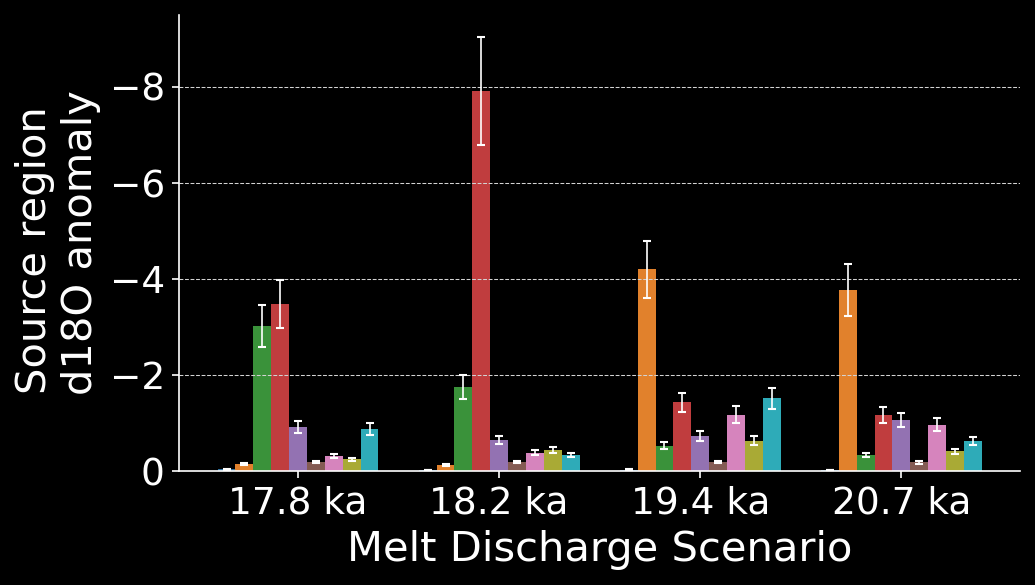

In [15]:
colores_sns = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:brown','tab:pink','tab:olive','tab:cyan']




# importing the required library
import seaborn as sns
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(7,4))
plt.style.use("dark_background")
plt.rcParams.update({
    "figure.figsize": (12, 8),        # bigger figure
    "figure.dpi": 150,                # high resolution
    "axes.titlesize": 24,             # title font
    "axes.labelsize": 20,             # axis label font
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
    "lines.linewidth": 3,             # thicker lines
    "lines.markersize": 8,
    "font.family": "sans-serif",
})



# Set your custom color palette
sns.set_palette(sns.color_palette(colores_sns))



# who v/s fare barplot 
ax = sns.barplot(x = 'variable',
            y = 'value',
            hue = 'Name',
            data = gdfm)


# Add error bars

# 🔸 Get the bar patches
#bar_patches = [p for p in ax.patches if p.get_width() != 0]
bar_patches = [p for p in ax.patches if isinstance(p, plt.Rectangle) and p.get_height() != 0]

# Sort patches top to bottom (because bars are horizontal now)
bar_patches = sorted(bar_patches, key=lambda p: p.get_x())

# Add error bars (horizontal now!)
for value, patch, err in zip(gdfm["value"],bar_patches, gdfe["errors"]):
    y = value #patch.get_width()
    x = patch.get_x() + patch.get_width() / 2
    ax.errorbar(x, y, yerr=err, fmt='none', c='white', capsize=2, elinewidth=0.8)


#ax.errorbar(y=np.arange(len(gdfe['errors']))/4, x=gdfm['value'], xerr=gdfe['errors'],
#            fmt='none', c='white', capsize=3, capthick=1, elinewidth=1)



ax.set_xlabel("Melt Discharge Scenario")
ax.set_ylabel("Source region \nd18O anomaly")

ax.set_xticklabels(["17.8 ka","18.2 ka","19.4 ka","20.7 ka"])
# Reverse x-axis
ax.invert_yaxis()


# Move legend to bottom, outside plot, 3 rows of 3
#ax.legend(
#    loc='upper center',
#    bbox_to_anchor=(0.5, -0.15),
#    ncol=3,
    #title="Groups",
    #frameon=False  # Optional: remove legend box
#)
ax.legend_.remove() # i have legend already

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, color='lightgray', linestyle='--', linewidth=0.5)

plt.tight_layout()
#plt.savefig("temp_output/fig1b.png")

plt.savefig("MeltDischarge_d18Oregional.png", transparent=True, dpi=300, bbox_inches='tight')



/tmp/ipykernel_38193/1319860524.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["17.8 ka","18.2 ka","19.4 ka","20.7 ka"])


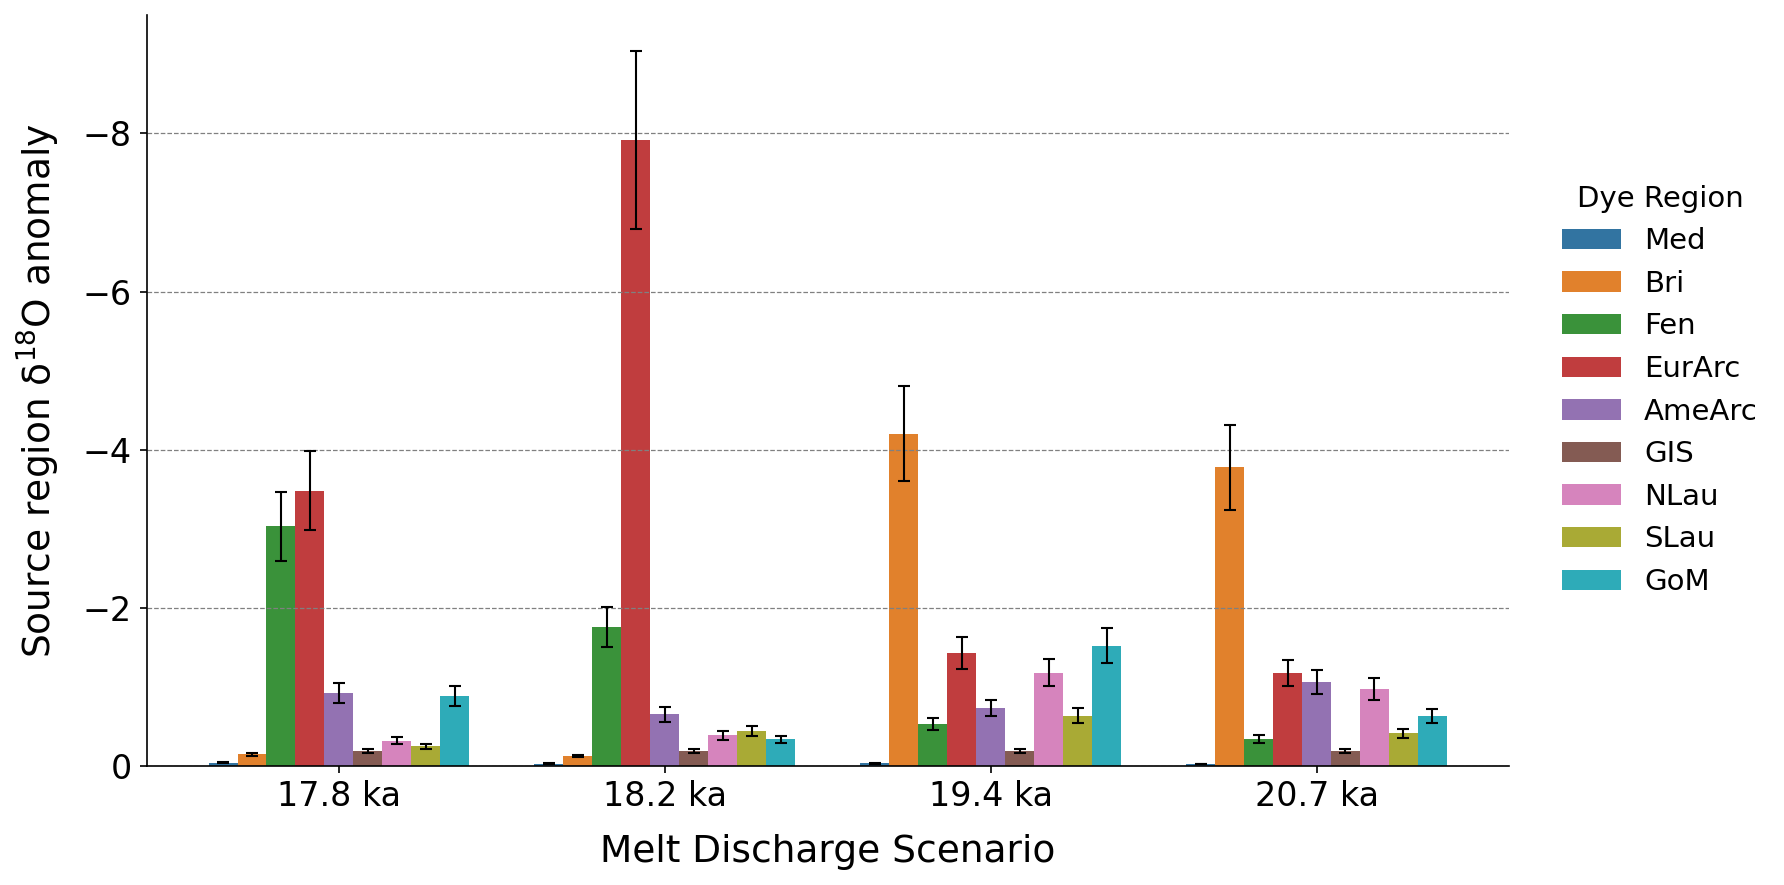

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Your custom colors and dye names
colores_sns = [
    'tab:blue','tab:orange','tab:green','tab:red',
    'tab:purple','tab:brown','tab:pink','tab:olive','tab:cyan'
]
dye_names = [
    "Med","Bri","Fen","EurArc","AmeArc",
    "GIS","NLau","SLau","GoM"
]

# --- Styling ---
plt.style.use("default")  # light background
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 150,
    "axes.titlesize": 22,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
    "lines.linewidth": 2.5,
    "lines.markersize": 7,
    "font.family": "sans-serif",
})

# --- Plot ---
sns.set_palette(sns.color_palette(colores_sns))

fig, ax = plt.subplots()

# Barplot
ax = sns.barplot(
    x="variable", 
    y="value", 
    hue="Name", 
    data=gdfm,
    errorbar=None,  # we'll add manual error bars
    ax=ax
)

# --- Add error bars ---
bar_patches = [p for p in ax.patches if isinstance(p, plt.Rectangle) and p.get_height() != 0]
bar_patches = sorted(bar_patches, key=lambda p: p.get_x())

for value, patch, err in zip(gdfm["value"], bar_patches, gdfe["errors"]):
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_height()
    ax.errorbar(x, y, yerr=err, fmt="none", 
                c="black", capsize=3, elinewidth=1, capthick=1)

# --- Axis labels and ticks ---
ax.set_xlabel("Melt Discharge Scenario", labelpad=10)
ax.set_ylabel("Source region δ$^{18}$O anomaly", labelpad=10)
ax.set_xticklabels(["17.8 ka","18.2 ka","19.4 ka","20.7 ka"])
ax.invert_yaxis()  # keep your reverse axis

# --- Legend on the right ---
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, dye_names,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    title="Dye Region",
    title_fontsize=14   # 🔹 make legend title bigger
)

# --- Cleanup ---
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, color="gray", linestyle="--", linewidth=0.6)

plt.tight_layout()
plt.savefig("MeltDischarge_d18Oregional.png", transparent=False, dpi=300, bbox_inches="tight")
plt.show()


In [24]:
gdg.to_csv("melt_in_region_with_d18O.csv")

In [34]:
# Load Dyes

ds_dye_zonal = xr.open_dataset('myintermediates/dyestuff_modelpaper/mean_dye_zonal.nc')
ds_dye_cold = xr.open_dataset('myintermediates/dyestuff_modelpaper/mean_dye_cold.nc')
ds_dye_merid = xr.open_dataset('myintermediates/dyestuff_modelpaper/mean_dye_merid.nc')


dict_dye = {'zonal' : ds_dye_zonal,
     'cold' : ds_dye_cold,
     'merid' : ds_dye_merid
    }

gdf_list = ['17.8ka','18.2 ka','19.4 ka','20.7 ka']


In [40]:

for mode, ds_dye in dict_dye.items():

    for j in range(4):
        for i in range(9):
            ds_dye[f'{gdf_list[j]} dye0{i} d18O'] = ds_dye[f'dye0{i}']*gdg[f'mean (-35.0) region d18O anomaly {gdf_list[j]}'][i]
        
        ds_dye[f'{gdf_list[j]} total d18O'] = ds_dye[f'{gdf_list[j]} dye00 d18O'] + ds_dye[f'{gdf_list[j]} dye01 d18O'] + ds_dye[f'{gdf_list[j]} dye02 d18O'] + ds_dye[f'{gdf_list[j]} dye03 d18O'] + ds_dye[f'{gdf_list[j]} dye04 d18O'] + ds_dye[f'{gdf_list[j]} dye05 d18O'] + ds_dye[f'{gdf_list[j]} dye06 d18O'] + ds_dye[f'{gdf_list[j]} dye07 d18O'] + ds_dye[f'{gdf_list[j]} dye08 d18O']




In [42]:
dict_dye['zonal']['20.7 ka total d18O']

<xarray.DataArray '20.7 ka total d18O' (lat: 144, lon: 288)>
array([[-0.        , -0.        , -0.        , ..., -0.        ,
        -0.        , -0.        ],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       ...,
       [-0.31560302, -0.3162287 , -0.31686452, ..., -0.31381917,
        -0.31439736, -0.3149918 ],
       [-0.31849048, -0.3189261 , -0.31936195, ..., -0.31719494,
        -0.31762347, -0.31805578],
       [-0.        , -0.        , -0.        , ..., -0.        ,
        -0.        , -0.        ]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.38 -88.12 -86.88 -85.62 ... 86.88 88.12 89.38
  * lon      (lon) float32 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8

In [60]:
#The four snapshots minima, and mean over NA

lon_min, lon_max = -80, 0
lat_min, lat_max = 20, 65

for j in range(4):#4
    for i,mode in enumerate(['cold','zonal','merid']):
        print(f'{gdf_list[j]}_{mode}:',dict_dye[mode][f'{gdf_list[j]} total d18O'].min())
        dict_dye[mode][f'{gdf_list[j]} total d18O mean NA'] = dict_dye[mode][f'{gdf_list[j]} total d18O'].sel(lat=slice(lat_min,lat_max),lon=slice(lon_min,lon_max)).mean()


   




17.8ka_cold: <xarray.DataArray '17.8ka total d18O' ()>
array(-3.8877823, dtype=float32)
17.8ka_zonal: <xarray.DataArray '17.8ka total d18O' ()>
array(-3.6961496, dtype=float32)
17.8ka_merid: <xarray.DataArray '17.8ka total d18O' ()>
array(-3.6109667, dtype=float32)
18.2 ka_cold: <xarray.DataArray '18.2 ka total d18O' ()>
array(-8.473558, dtype=float32)
18.2 ka_zonal: <xarray.DataArray '18.2 ka total d18O' ()>
array(-8.066731, dtype=float32)
18.2 ka_merid: <xarray.DataArray '18.2 ka total d18O' ()>
array(-7.916918, dtype=float32)
19.4 ka_cold: <xarray.DataArray '19.4 ka total d18O' ()>
array(-1.912314, dtype=float32)
19.4 ka_zonal: <xarray.DataArray '19.4 ka total d18O' ()>
array(-1.6255571, dtype=float32)
19.4 ka_merid: <xarray.DataArray '19.4 ka total d18O' ()>
array(-1.5776055, dtype=float32)
20.7 ka_cold: <xarray.DataArray '20.7 ka total d18O' ()>
array(-1.6995705, dtype=float32)
20.7 ka_zonal: <xarray.DataArray '20.7 ka total d18O' ()>
array(-1.4040873, dtype=float32)
20.7 ka_merid

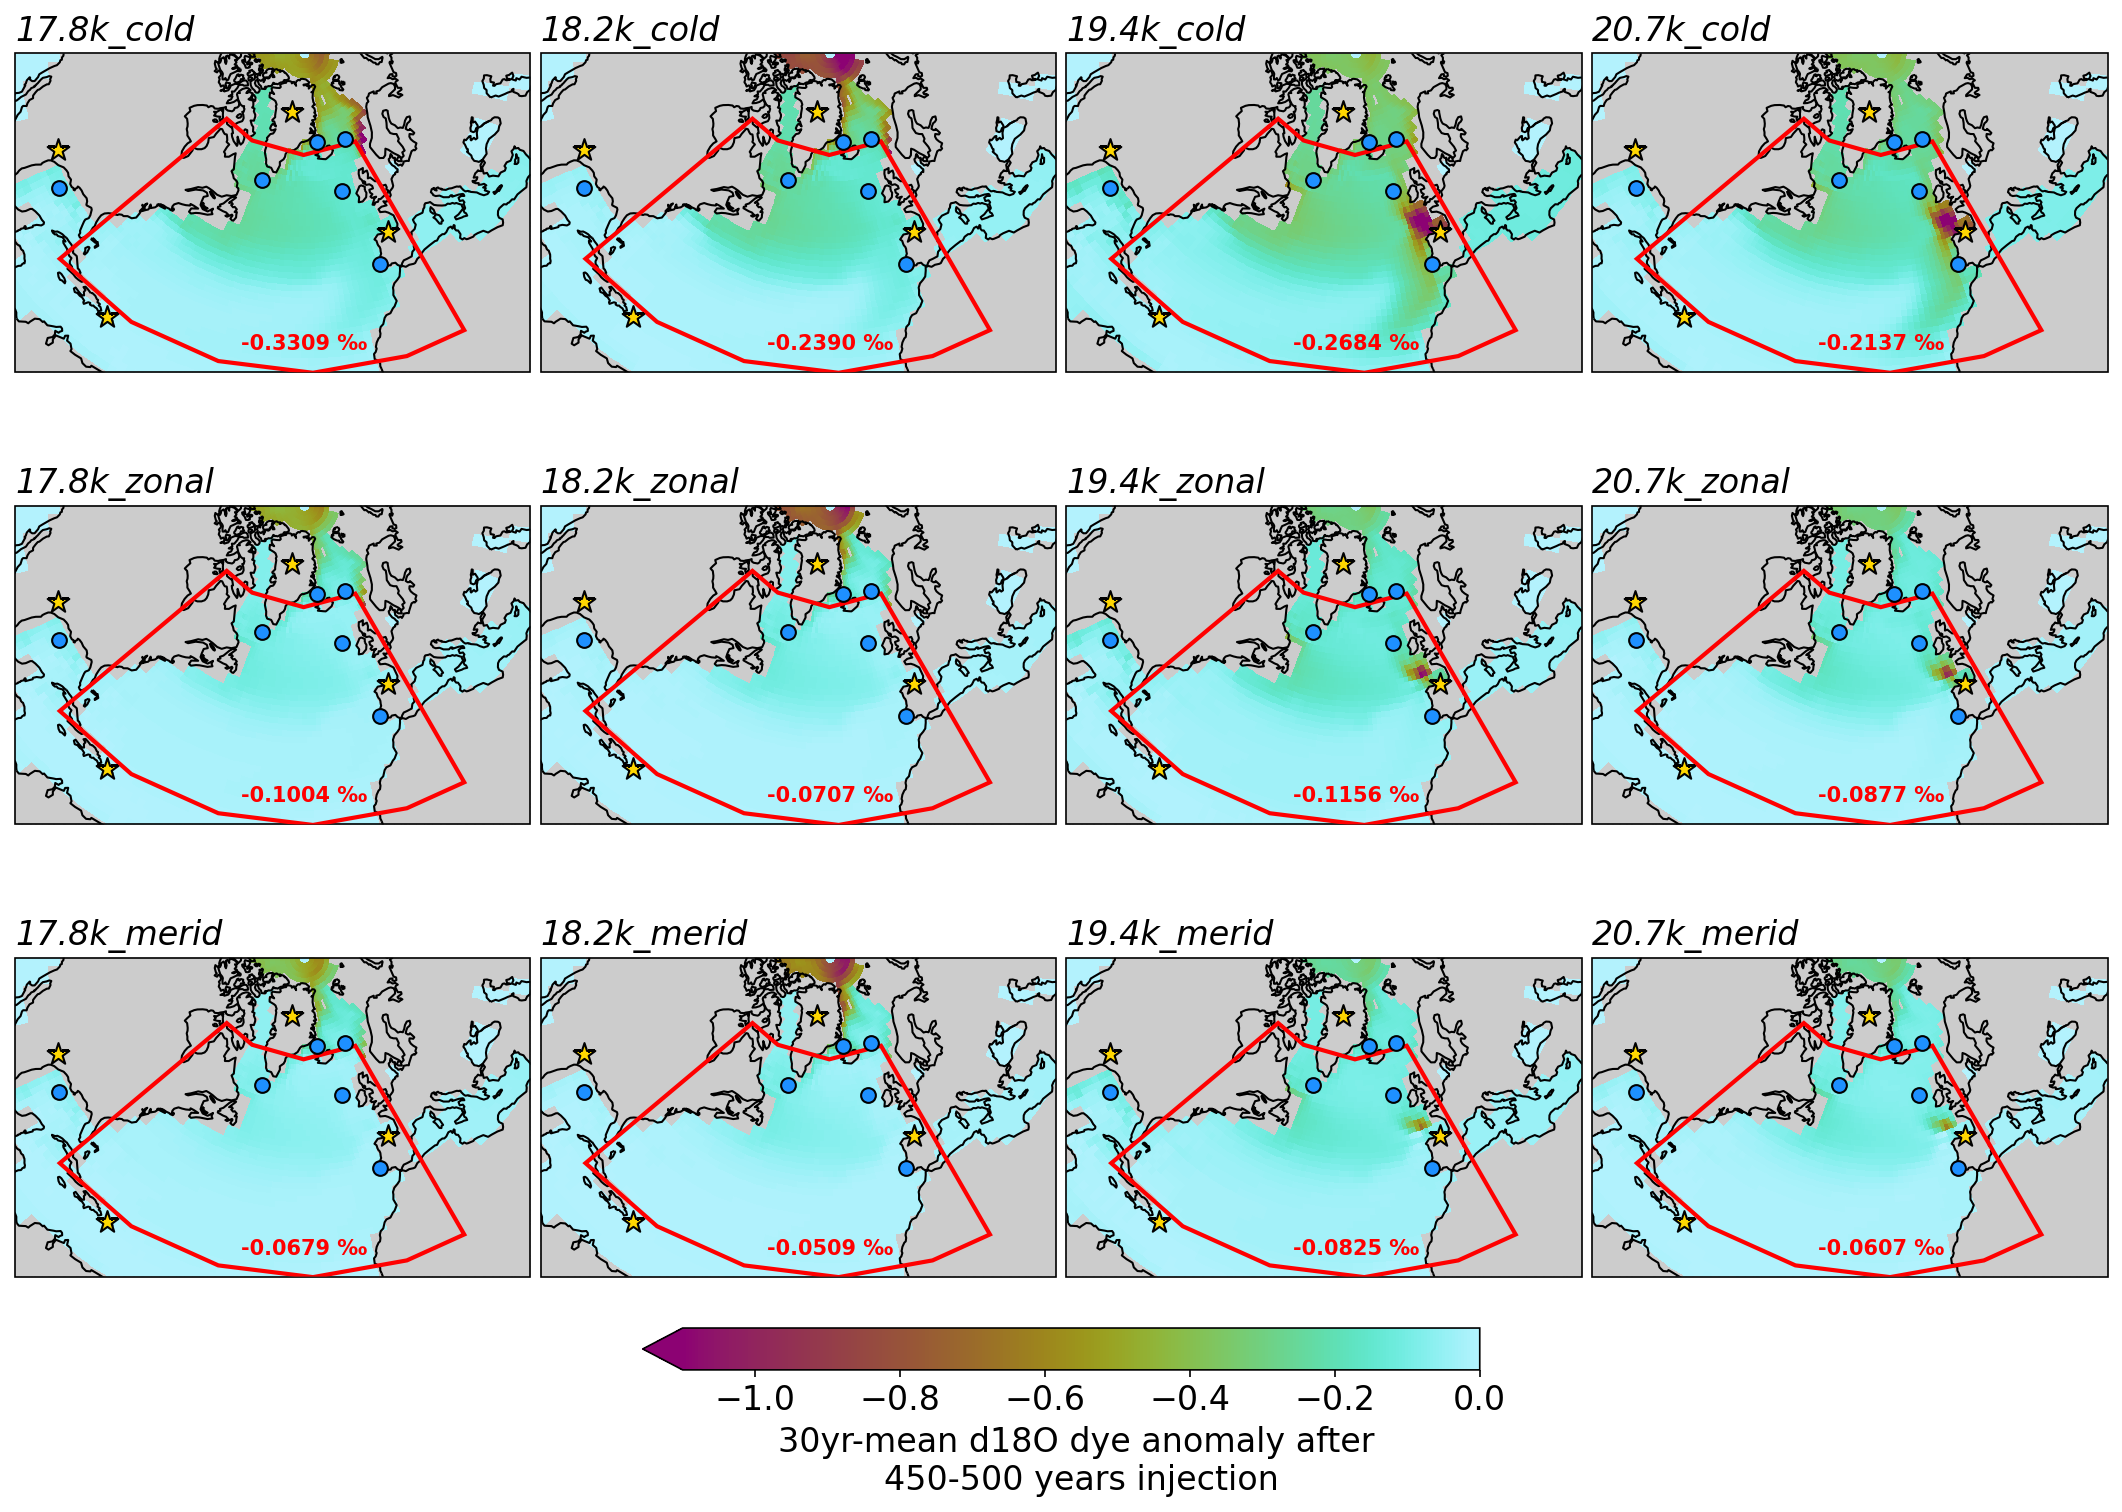

In [67]:
# Plot for Each AMOC mode Anomaly Field
### aft450-500 years of injection. how does the total surface map look for the for scenarios for AMOC modes?

land_sites_name = ["NISA","NGRIP","Puerto","NoName"]
land_sites_lon = [360-4.8,360-42.3167,360-66.8,360-98.63]
land_sites_lat = [43.41,75.1,18.32,29.87]

#ocean_sites_name = ["GIN","BOB","BER"]
ocean_sites_lon = [360-4.5667,360-21.7667,360-48.6,360-14.7,360-10.1667,360-91.345300]
ocean_sites_lat = [66.6833, 67.8667, 57.4333, 55.4833, 37.8, 26.946700]

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import matplotlib.ticker as mticker

# scenarios
exp_n = ["17.8k", "18.2k", "19.4k", "20.7k"]
exp_list = ["xpral", "xpujm", "xpujj", "xpujg"]

import matplotlib.patches as mpatches
from matplotlib import colors

plt.rcParams.update({
    "figure.figsize": (12, 8),        # bigger figure
    "figure.dpi": 150,                # high resolution
    "axes.titlesize": 16,             # title font
    "axes.labelsize": 20,             # axis label font
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
    "lines.linewidth": 3,             # thicker lines
    "lines.markersize": 8,
    "font.family": "sans-serif",
})

#projection_map = ccrs.NearsidePerspective(central_longitude=-35, central_latitude=45, satellite_height=11000000)
# Define the Lambert Azimuthal Equal-Area projection centered on the Northern Hemisphere
#projection_map = ccrs.LambertAzimuthalEqualArea(central_longitude=-40, central_latitude=60)

#projection_map = ccrs.PlateCarree()
projection_map = ccrs.NorthPolarStereo(central_longitude=-30)

#Def
figMap,(axMap) = plt.subplots(nrows=3, ncols=4, subplot_kw={'projection':projection_map}, figsize=(18,14))
#axMap = axMap.flatten()
normdye = colors.Normalize(vmin=0,vmax=0.05)
normd18O = colors.Normalize(vmin=0,vmax=-1.)
normdyediff = colors.TwoSlopeNorm(vmin=-0.05, vcenter=0., vmax=0.05)

#The four snapshots
for j in range(4):#4
    for i,mode in enumerate(['cold','zonal','merid']):
        # Set the extent to focus on the Northern Hemisphere including Iberia and Gulf of Mexico
        axMap[i,j].set_extent([-95, 15, 20, 90], crs=ccrs.PlateCarree())
        axMap[i,j].coastlines(zorder=10)
        axMap[i,j].pcolormesh(lsm.longitude, lsm.latitude,xr.where(lsm==0, np.nan,lsm),
                      #cmap=ListedColormap(['xkcd:pale brown']), 
                      cmap=ListedColormap(['#cccccc']),
                      #cmap=ListedColormap(['#EEEEEE']),         
                      transform=ccrs.PlateCarree(),
                      shading="nearest",
                      zorder=1)
        cmap = axMap[i,j].pcolormesh(lon_dis_b, lat_dis_b,
                                     dict_dye[mode][f'{gdf_list[j]} total d18O'], transform=ccrs.PlateCarree(), 
                        norm=normd18O,
                        cmap=cmc.hawaii, alpha=1)
    
        #axMap[i,j].set_title(f'{gdf_list[j]}',loc='left',fontsize=24)
        # experiment label box
        axMap[i,j].set_title(f"{exp_n[j]}_{mode}", loc="left", fontstyle="italic")
        


        # add red rectangle
        width = lon_max - lon_min
        height = lat_max - lat_min
        rect = mpatches.Rectangle(
            (lon_min, lat_min), width, height,
            linewidth=2, edgecolor='red', facecolor='none',
            transform=ccrs.PlateCarree(), zorder=50
        )
        axMap[i,j].add_patch(rect)

        # --- add average value inside the rectangle (bottom-right corner) ---
        avg_val = dict_dye[mode][f'{gdf_list[j]} total d18O mean NA']  # your variable
        axMap[i,j].text(
            -30, 25, f"{avg_val:.4f} ‰",  # place at bottom-right of rectangle
            color='red', fontsize=10, fontweight='bold',
            ha='center', va='center',
            transform=ccrs.PlateCarree(),
            zorder=60
        )


        # --- inside your plotting loop, after axMap[i,j].pcolormesh(...) ---

        # plot land sites (stars)
        axMap[i,j].scatter(
            land_sites_lon, land_sites_lat,
            transform=ccrs.PlateCarree(),
            marker="*", c="gold", s=120, edgecolor="black", zorder=100,
            label="Land sites" if (i == 0 and j == 0) else None
        )
    
        
        # plot ocean sites (circles)
        axMap[i,j].scatter(
            ocean_sites_lon, ocean_sites_lat,
            transform=ccrs.PlateCarree(),
            marker="o", c="dodgerblue", s=50, edgecolor="black", zorder=90,
            label="Ocean sites" if (i == 0 and j == 0) else None
        )
    
        # add legend only once (top-left subplot)
        #if i == 0 and j == 0:
         #   axMap[i,j].legend(loc="lower left", fontsize=10, frameon=True)

cb = plt.colorbar(cmap,ax=axMap, shrink=0.4,location="bottom",extend='min')
cb.set_label(f"30yr-mean d18O dye anomaly after \n450-500 years injection", size=16)
cb.ax.tick_params(labelsize=16)

# --- Adjust spacing ---
plt.subplots_adjust(wspace=0.02, hspace=0.08, bottom=0.25)



#plt.tight_layout()


plt.savefig(f'scenarios_d18O_maps.png',dpi=300,transparent=False)



In [6]:
# Initial Calculations

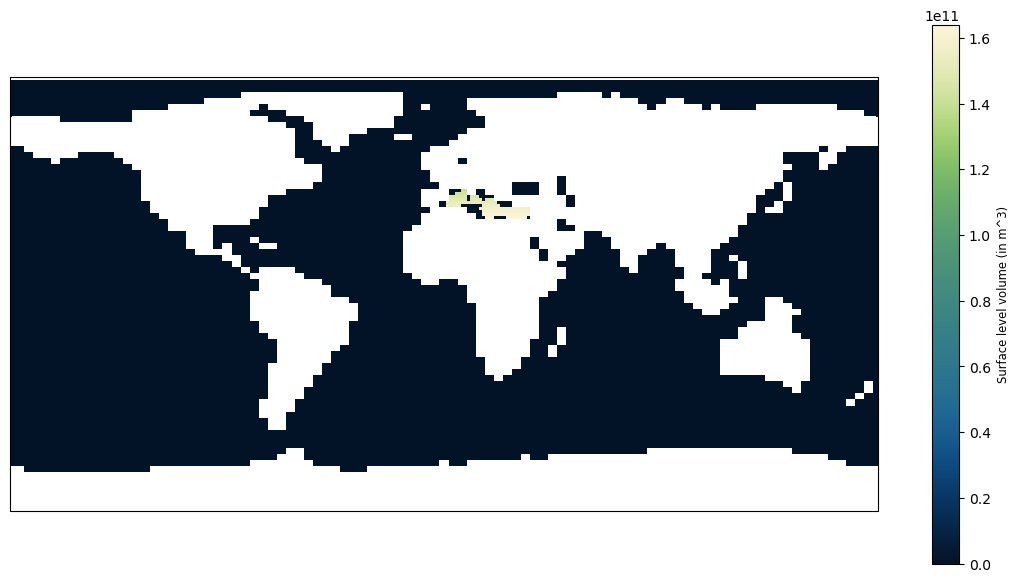

In [6]:
# Multiply with region to get the volume as a sum.


projection_map = ccrs.PlateCarree()
#projection_map = ccrs.NearsidePerspective(central_longitude=-35, central_latitude=45, satellite_height=11000000)
figMap,axMap = plt.subplots(nrows=1, ncols=1, subplot_kw={'projection':projection_map}, figsize=(14,7))

cmap = axMap.pcolormesh(lon_dis_b, lat_dis_b,ds_dyeregion["surface_volume"]*ds_dyeregion["Med"].isel(depth=0,t=0), transform=ccrs.PlateCarree(), 
                        #norm=normSST,
                        cmap=cmc.navia, alpha=1)

cb = plt.colorbar(cmap,ax=axMap)
cb.set_label(f"Surface level volume (in m^3)", size='small')


In [ ]:
### Surface volume in the dataset

#gdf['surface volume']

# Create empty array for result
region_vol = np.empty((len(dyen)-1))

for i in range(len(region_vol)):
    region_vol[i] = (ds_dyeregion["surface_volume"]*ds_dyeregion[dyen[i+1]].isel(depth=0,t=0)).sum().item()

gdf['surface volume (m^3)']=region_vol 

$region_{d18O} = \frac{((region_{surfacevolume}*0)+(region_{meltsvyr}*input_{d18O}))}{(region_{surfacevolume}+(region_{meltsvyr}))}$


In [ ]:
sv_to_yr = 10**6*31536000 #m^3 /s * s/yr

gdf['target -5 (d18O)'] = -5*(gdf['surface volume (m^3)']+gdf[f'Region Melt 17.8ka (Sv)']*sv_to_yr)/(gdf[f'Region Melt 17.8ka (Sv)']*sv_to_yr)

In [ ]:
# Boundary conditions for d18O of input meltwater
min_ice_d18O = -40.0 #permil d18O
mean_ice_d18O = -35.0 #permil d18O
max_ice_d18O = -30.0 #permil d18O

sv_to_yr = 10**6*31536000 #m^3 /s * s/yr

# Calculate the regional d18O value of the seawater in the source region (this is 1 of my tracer value!)
for sce in (['17.8ka','18.2 ka','19.4 ka','20.7 ka']):
    gdf[f'max ({max_ice_d18O}) region d18O anomaly {sce}'] = ((gdf['surface volume (m^3)']*0)+(gdf[f'Region Melt {sce} (Sv)']*sv_to_yr*max_ice_d18O))/(gdf['surface volume (m^3)']+sv_to_yr*gdf[f'Region Melt {sce} (Sv)'])
    gdf[f'min ({min_ice_d18O}) region d18O anomaly {sce}'] = ((gdf['surface volume (m^3)']*0)+(gdf[f'Region Melt {sce} (Sv)']*sv_to_yr*min_ice_d18O))/(gdf['surface volume (m^3)']+sv_to_yr*gdf[f'Region Melt {sce} (Sv)'])
    gdf[f'mean ({mean_ice_d18O}) region d18O anomaly {sce}'] = ((gdf['surface volume (m^3)']*0)+(gdf[f'Region Melt {sce} (Sv)']*sv_to_yr*mean_ice_d18O))/(gdf['surface volume (m^3)']+sv_to_yr*gdf[f'Region Melt {sce} (Sv)'])
    gdf[f'error region d18O anomaly {sce}']= (gdf[f'max ({max_ice_d18O}) region d18O anomaly {sce}']-gdf[f'min ({min_ice_d18O}) region d18O anomaly {sce}'])/2
    gdf[f'Region melt volume {sce}'] = gdf[f'Region Melt {sce} (Sv)']*sv_to_yr

In [ ]:
gdf

In [ ]:
gdfm = gdf.melt(id_vars="Name",value_vars=[f"mean ({mean_ice_d18O}) region d18O anomaly 17.8ka",
                                    f"mean ({mean_ice_d18O}) region d18O anomaly 18.2 ka",
                                    f"mean ({mean_ice_d18O}) region d18O anomaly 19.4 ka",
                                    f"mean ({mean_ice_d18O}) region d18O anomaly 20.7 ka"])
gdfe = gdf.melt(id_vars="Name",value_vars=[f"error region d18O anomaly 17.8ka",
                                    f"error region d18O anomaly 18.2 ka",
                                    f"error region d18O anomaly 19.4 ka",
                                    f"error region d18O anomaly 20.7 ka"],value_name="errors")



In [ ]:
gdfe

In [ ]:
#gdf.to_pickle("myintermediates/regionalmeltdischarge_withd18O.pkl")

In [151]:
ax.patches

<Axes.ArtistList of 45 patches>

/tmp/ipykernel_17151/1628944371.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["17.8 ka","18.2 ka","19.4 ka","20.7 ka"])


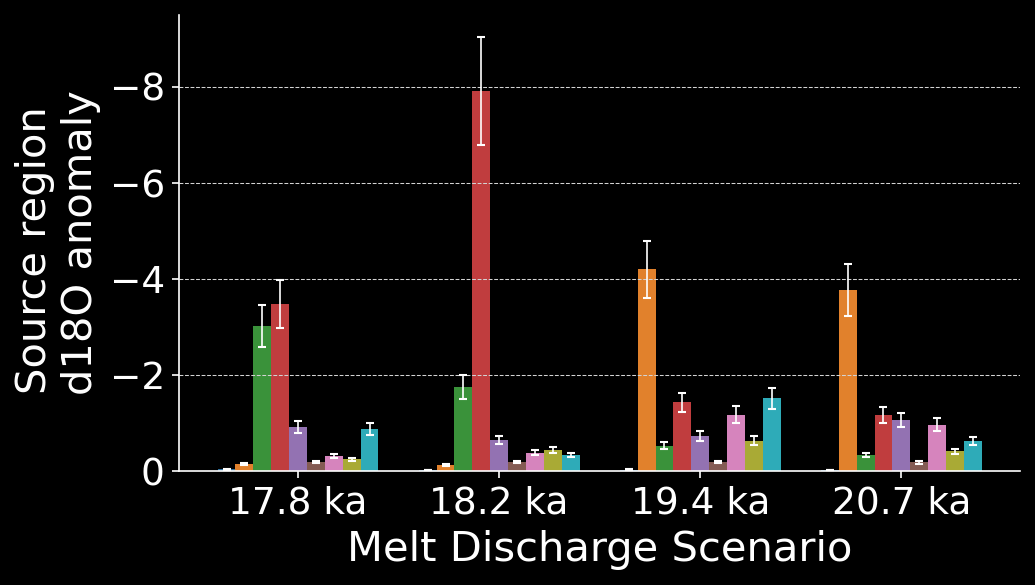

In [31]:
colores_sns = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:brown','tab:pink','tab:olive','tab:cyan']




# importing the required library
import seaborn as sns
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(7,4))
plt.style.use("dark_background")
plt.rcParams.update({
    "figure.figsize": (12, 8),        # bigger figure
    "figure.dpi": 150,                # high resolution
    "axes.titlesize": 24,             # title font
    "axes.labelsize": 20,             # axis label font
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
    "lines.linewidth": 3,             # thicker lines
    "lines.markersize": 8,
    "font.family": "sans-serif",
})



# Set your custom color palette
sns.set_palette(sns.color_palette(colores_sns))



# who v/s fare barplot 
ax = sns.barplot(x = 'variable',
            y = 'value',
            hue = 'Name',
            data = gdfm)


# Add error bars

# 🔸 Get the bar patches
#bar_patches = [p for p in ax.patches if p.get_width() != 0]
bar_patches = [p for p in ax.patches if isinstance(p, plt.Rectangle) and p.get_height() != 0]

# Sort patches top to bottom (because bars are horizontal now)
bar_patches = sorted(bar_patches, key=lambda p: p.get_x())

# Add error bars (horizontal now!)
for value, patch, err in zip(gdfm["value"],bar_patches, gdfe["errors"]):
    y = value #patch.get_width()
    x = patch.get_x() + patch.get_width() / 2
    ax.errorbar(x, y, yerr=err, fmt='none', c='white', capsize=2, elinewidth=0.8)


#ax.errorbar(y=np.arange(len(gdfe['errors']))/4, x=gdfm['value'], xerr=gdfe['errors'],
#            fmt='none', c='white', capsize=3, capthick=1, elinewidth=1)



ax.set_xlabel("Melt Discharge Scenario")
ax.set_ylabel("Source region \nd18O anomaly")

ax.set_xticklabels(["17.8 ka","18.2 ka","19.4 ka","20.7 ka"])
# Reverse x-axis
ax.invert_yaxis()


# Move legend to bottom, outside plot, 3 rows of 3
#ax.legend(
#    loc='upper center',
#    bbox_to_anchor=(0.5, -0.15),
#    ncol=3,
    #title="Groups",
    #frameon=False  # Optional: remove legend box
#)
ax.legend_.remove() # i have legend already

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, color='lightgray', linestyle='--', linewidth=0.5)

plt.tight_layout()
#plt.savefig("temp_output/fig1b.png")

plt.savefig("MeltDischarge_d18Oregional.png", transparent=True, dpi=300, bbox_inches='tight')



In [18]:
# Look now at the signal when scaling to the dye data
# Load dye data (takes around 500s)
exp_list = ('xpraj','xprak','xpram', #17.8
            'xpujl','xpujm', #18.2
            'xpuji','xpujj','xpujk', #19.4
            'xpujf','xpujg','xpujh' #20.7
           )
ds_dye = {}

with mf.Timer('data loading'):
    for exp in exp_list:
        try:
            ds_dye[exp] = xr.open_mfdataset(f'/nfs/annie/earpal/database/experiments/{exp}/time_series/{exp}.dye0?.annual.nc',parallel=True)
    
            old_name=list(ds_dye[exp].data_vars)
            ds_dye[exp] = ds_dye[exp].rename_vars({old_name[0]: 'dye00',
                                            old_name[1]: 'dye01',
                                            old_name[2]: 'dye02',
                                            old_name[3]: 'dye03',
                                            old_name[4]: 'dye04',
                                            old_name[5]: 'dye05',
                                            old_name[6]: 'dye06',
                                            old_name[7]: 'dye07',
                                            old_name[8]: 'dye08',
                                            old_name[9]: 'dye09',})
        except ValueError as e:
            print(f"error in {exp}")

[data loading]
Elapsed: 462.7948331832886


In [55]:
ds_dye

{'xpraj': <xarray.Dataset>
 Dimensions:    (depth_1: 20, latitude: 144, longitude: 288, t: 500)
 Coordinates:
   * depth_1    (depth_1) float32 5.0 15.0 25.0 ... 3.962e+03 4.577e+03 5.192e+03
   * latitude   (latitude) float32 -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
   * longitude  (longitude) float32 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
   * t          (t) object 5681-06-01 00:00:00 ... 6180-06-01 00:00:00
 Data variables:
     dye00      (t, depth_1, latitude, longitude) float32 dask.array<chunksize=(500, 20, 144, 288), meta=np.ndarray>
     dye01      (t, depth_1, latitude, longitude) float32 dask.array<chunksize=(500, 20, 144, 288), meta=np.ndarray>
     dye02      (t, depth_1, latitude, longitude) float32 dask.array<chunksize=(500, 20, 144, 288), meta=np.ndarray>
     dye03      (t, depth_1, latitude, longitude) float32 dask.array<chunksize=(500, 20, 144, 288), meta=np.ndarray>
     dye04      (t, depth_1, latitude, longitude) float32 dask.array<chunksize=(500, 20, 144

In [58]:
ds_dye['xpraj'][dye_list[i]]

<xarray.DataArray 'dye00' (t: 500, depth_1: 20, latitude: 144, longitude: 288)>
dask.array<open_dataset-otracer1_ym_dpth, shape=(500, 20, 144, 288), dtype=float32, chunksize=(500, 20, 144, 288), chunktype=numpy.ndarray>
Coordinates:
  * depth_1    (depth_1) float32 5.0 15.0 25.0 ... 3.962e+03 4.577e+03 5.192e+03
  * latitude   (latitude) float32 -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * longitude  (longitude) float32 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * t          (t) object 5681-06-01 00:00:00 ... 6180-06-01 00:00:00
Attributes:
    source:      Unified Model Output (Vn 4.6):
    name:        otracer1_ym_dpth
    title:       OCN EXTRACER  1: CONVEN TCO2
    date:        01/12/80
    time:        00:00
    long_name:   OCN EXTRACER  1: CONVEN TCO2
    stash_code:  103
    submodel:    2
    processing:  yearly_mean_depth_levels
    units:        
    valid_min:   -0.0012033834
    valid_max:   0.06830346

In [113]:
zonal_list = ['xprak','xpujm','xpujj','xpujg']
cold_list = ['xpraj','xpujl','xpuji','xpujf']
gdf_list = ['17.8ka','18.2 ka','19.4 ka','20.7 ka']

for j,exp in enumerate(cold_list):

    for i in range(9):
        ds_dye[exp][f'dye0{i} d18O'] = ds_dye[exp][f'dye0{i}']*gdf[f'mean (-35.0) region d18O anomaly {gdf_list[j]}'][i]
    
    ds_dye[exp]['total d18O'] = ds_dye[exp][f'dye00 d18O'] + ds_dye[exp][f'dye01 d18O'] + ds_dye[exp][f'dye02 d18O'] + ds_dye[exp][f'dye03 d18O'] + ds_dye[exp][f'dye04 d18O'] + ds_dye[exp][f'dye05 d18O'] + ds_dye[exp][f'dye06 d18O'] + ds_dye[exp][f'dye07 d18O'] + ds_dye[exp][f'dye08 d18O']


for j,exp in enumerate(zonal_list):

    for i in range(9):
        ds_dye[exp][f'dye0{i} d18O'] = ds_dye[exp][f'dye0{i}']*gdf[f'mean (-35.0) region d18O anomaly {gdf_list[j]}'][i]
    
    ds_dye[exp]['total d18O'] = ds_dye[exp][f'dye00 d18O'] + ds_dye[exp][f'dye01 d18O'] + ds_dye[exp][f'dye02 d18O'] + ds_dye[exp][f'dye03 d18O'] + ds_dye[exp][f'dye04 d18O'] + ds_dye[exp][f'dye05 d18O'] + ds_dye[exp][f'dye06 d18O'] + ds_dye[exp][f'dye07 d18O'] + ds_dye[exp][f'dye08 d18O'] 



In [1]:
gdf_list[j]

NameError: name 'gdf_list' is not defined

In [116]:
zonal_list[i-4]

'xprak'

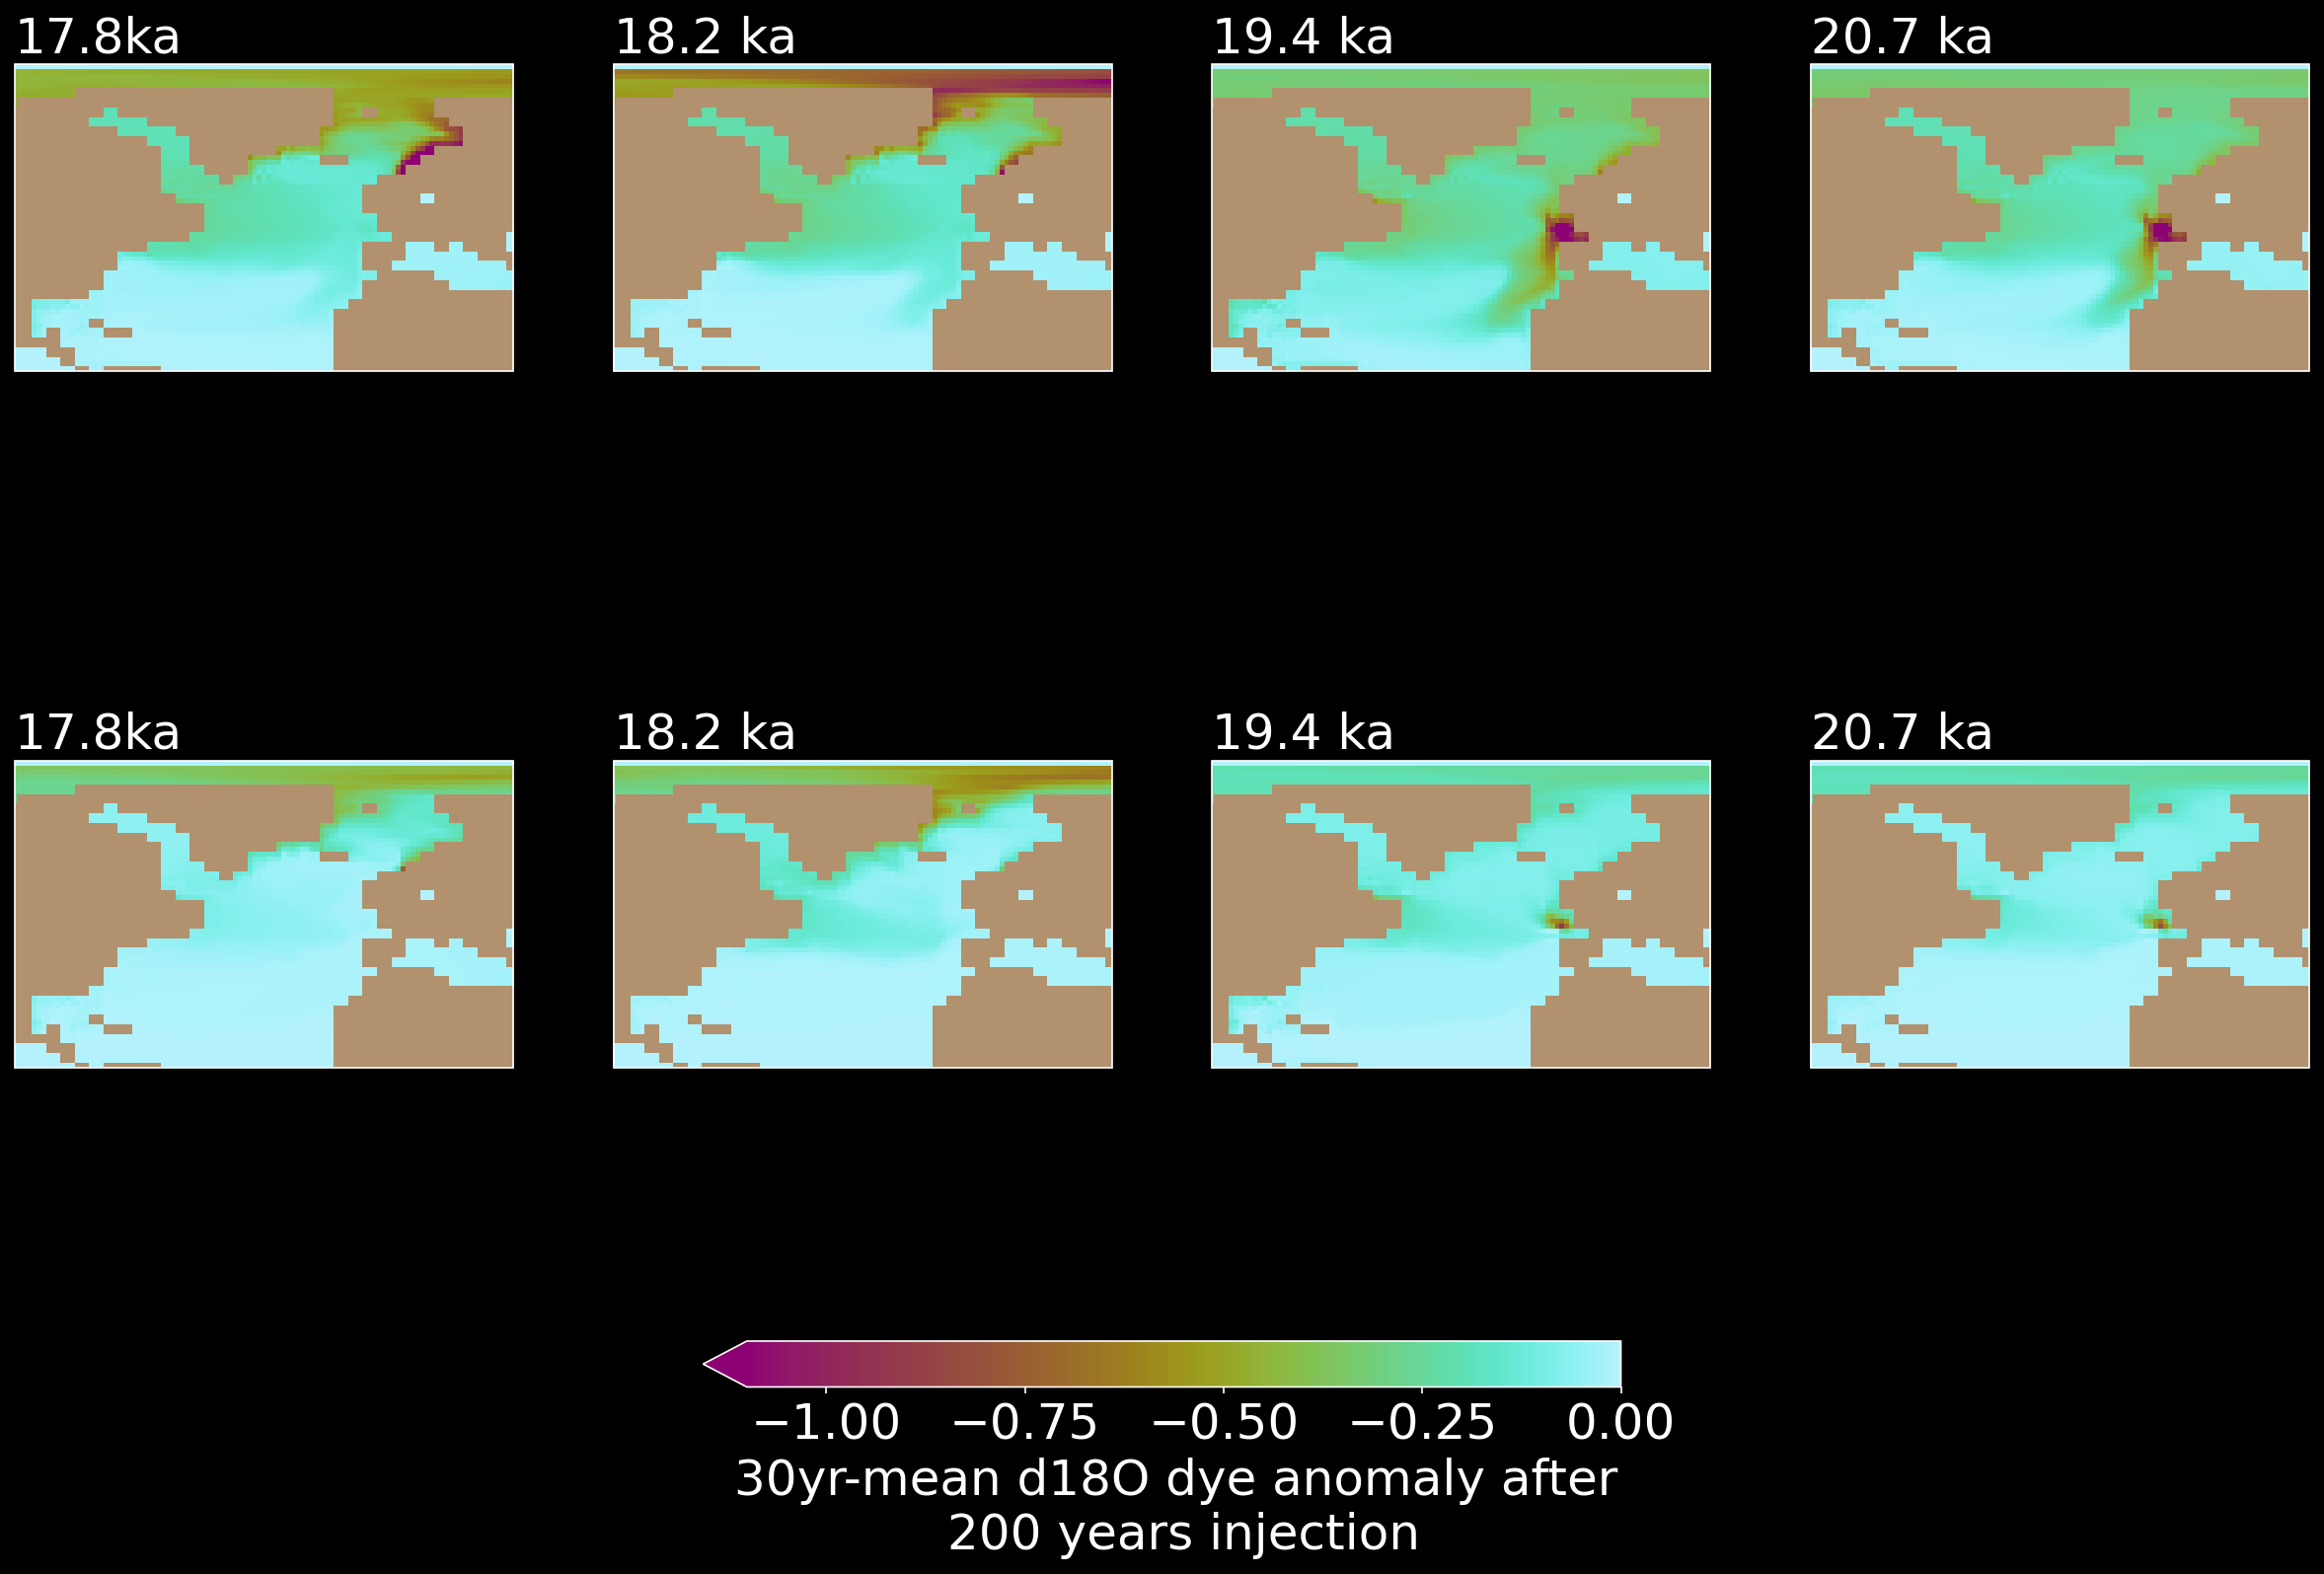

In [117]:
### after 200 years of injection. how does the total surface map look for the for scenarios for strong vs weak AMOC?

#Same map for all 4 scenarios & two different states
#For EGU, with cold and zonal mode

from matplotlib import colors

#make a plot for me or EGU poster 2025
plt.style.use("dark_background")  # 🌑 not dark background

plt.rcParams.update({
    "figure.figsize": (12, 8),        # bigger figure
    "figure.dpi": 150,                # high resolution
    "axes.titlesize": 24,             # title font
    "axes.labelsize": 20,             # axis label font
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
    "lines.linewidth": 3,             # thicker lines
    "lines.markersize": 8,
    "font.family": "sans-serif",
})

projection_map = ccrs.NearsidePerspective(central_longitude=-35, central_latitude=45, satellite_height=11000000)
# Define the Lambert Azimuthal Equal-Area projection centered on the Northern Hemisphere
#projection_map = ccrs.LambertAzimuthalEqualArea(central_longitude=-40, central_latitude=60)

projection_map = ccrs.PlateCarree()



dyen = ('Med Sea','British','Fennoscandia','Eurasian Arctic','Am. Arctic','GIS','N Laurentide','S Laurentide','Gulf of Mexico')
vmax_list = (0.6,1.2,0.6,0.6,0.8,0.6,0.6,0.6,0.5,0.5)

vminl = 0.0000001
t_snap= 200
dye_list=('dye00','dye01','dye02','dye03','dye04','dye05','dye06','dye07','dye08')
dye_names=(f'Med \nSea',f'British \nisles',f'Fenno- \nscandia',f'Eurasian \nArctic',f'American \nArctic',f'Eastern \nGIS',f'North \nLaurentide',f'South \nLaurentide',f'Gulf of \nMexico')
dye_abbrev=('Med','Bri','Fen','EurArc','AmeArc','GIS','NLau','SLau','GulofMex')
simn=exp_list




#Def
figMap,(axMap) = plt.subplots(nrows=2, ncols=4, subplot_kw={'projection':projection_map}, figsize=(20,16))
axMap = axMap.flatten()
normdye = colors.Normalize(vmin=0,vmax=0.05)
normd18O = colors.Normalize(vmin=0,vmax=-1.)
normdyediff = colors.TwoSlopeNorm(vmin=-0.05, vcenter=0., vmax=0.05)

#Dye
for i in range(4):
    # Set the extent to focus on the Northern Hemisphere including Iberia and Gulf of Mexico
    axMap[i].set_extent([-100, 30, 10, 90], crs=ccrs.PlateCarree())

    axMap[i].pcolormesh(lsm.longitude, lsm.latitude,xr.where(lsm==0, np.nan,lsm),
                      cmap=ListedColormap(['xkcd:pale brown']), 
                      #cmap=ListedColormap(['#EEEEEE']),         
                      transform=ccrs.PlateCarree(),
                      zorder=1)
    cmap = axMap[i].pcolormesh(lon_dis_b, lat_dis_b,ds_dye[cold_list[i]][f"total d18O"].isel(depth_1=0,t=slice(200,230)).mean(dim='t'), transform=ccrs.PlateCarree(), 
                        norm=normd18O,
                        cmap=cmc.hawaii, alpha=1)
    
    axMap[i].set_title(f'{gdf_list[i]}',loc='left',fontsize=24)


for i in range(4,8):
    # Set the extent to focus on the Northern Hemisphere including Iberia and Gulf of Mexico
    axMap[i].set_extent([-100, 30, 10, 90], crs=ccrs.PlateCarree())

    axMap[i].pcolormesh(lsm.longitude, lsm.latitude,xr.where(lsm==0, np.nan,lsm),
                      cmap=ListedColormap(['xkcd:pale brown']), 
                      #cmap=ListedColormap(['#EEEEEE']),         
                      transform=ccrs.PlateCarree(),
                      zorder=1)
    cmap = axMap[i].pcolormesh(lon_dis_b, lat_dis_b,ds_dye[zonal_list[i-4]][f"total d18O"].isel(depth_1=0,t=slice(200,230)).mean(dim='t'), transform=ccrs.PlateCarree(), 
                        norm=normd18O,
                        cmap=cmc.hawaii, alpha=1)
    
    axMap[i].set_title(f'{gdf_list[i-4]}',loc='left',fontsize=24)


#for i in range(9):
#    axMap[1,i].pcolormesh(lsm.longitude, lsm.latitude,xr.where(lsm==0, np.nan,lsm),
#                      cmap=ListedColormap(['xkcd:pale brown']), 
                      #cmap=ListedColormap(['#EEEEEE']),         
#                      transform=ccrs.PlateCarree(),
#                      zorder=1)
#    cmap = axMap[1,i].pcolormesh(lon_ds_b, lat_ds_b,ds_dye['xprak'][dye_list[i]].isel(depth_1=0,t=slice(200,230)).mean(dim='t'), transform=ccrs.PlateCarree(), 
#                        norm=normdye,
#                        cmap=cmc.navia, alpha=1)
#    axMap[1,i].pcolormesh(lon_ds_b, lat_ds_b,xr.where(ds_region[dye_abbrev[i]].isel(t=0).isel(depth=0)>0,ds_region[dye_abbrev[i]].isel(t=0).isel(depth=0),np.nan), transform=ccrs.PlateCarree(), 
#                                    clim=(0, 0.00000000001), alpha=0.5,cmap=cmc.buda_r)



#for i in range(9):
#    axMap[2,i].pcolormesh(lsm.longitude, lsm.latitude,xr.where(lsm==0, np.nan,lsm),
#                      cmap=ListedColormap(['xkcd:pale brown']), 
                      #cmap=ListedColormap(['#EEEEEE']),         
#                      transform=ccrs.PlateCarree(),
#                      zorder=1)
#    cmap2 = axMap[2,i].pcolormesh(lon_ds_b, lat_ds_b,(ds_dye['xpraj'][f'dye0{i}'].isel(t=slice(200,230)).mean(dim='t').isel(depth_1=0).clip(min=vminl)-
#                                                ds_dye['xprak'][f'dye0{i}'].isel(t=slice(200,230)).mean(dim='t').isel(depth_1=0).clip(min=vminl))
#                                                , transform=ccrs.PlateCarree(), 
#                        norm=normdyediff,
#                        cmap=cmc.vik_r, alpha=1)
#    axMap[2,i].pcolormesh(lon_ds_b, lat_ds_b,xr.where(ds_region[dye_abbrev[i]].isel(t=0).isel(depth=0)>0,ds_region[dye_abbrev[i]].isel(t=0).isel(depth=0),np.nan), transform=ccrs.PlateCarree(), 
#                                    clim=(0, 0.00000000001), alpha=0.5,cmap=cmc.buda_r)


    

cb = plt.colorbar(cmap,ax=axMap, shrink=0.4,location="bottom",extend='min')
cb.set_label(f"30yr-mean d18O dye anomaly after \n200 years injection", size=24)
cb.ax.tick_params(labelsize=24)

#cb2 = plt.colorbar(cmap2,ax=axMap[:,4:9],location="bottom",shrink=0.8,extend='both')
#cb2.set_label(f"30yr-mean difference in dye intensity (cold-warm) after \n200 years injection (Scenario 17.8 ka)", size=24)
#cb2.ax.tick_params(labelsize=24)


#plt.tight_layout()

#plt.savefig('temp_output/EGU_difffig.png',bbox_inches='tight')
plt.savefig('temp_output/EGU_2025fig_d18Omaps.png',bbox_inches='tight',dpi=300,transparent=True)

#plt.savefig(f'200yr_Sce178_All.png',dpi=300,transparent=False)

#plt.tight_layout()


In [76]:
from matplotlib.patches import Rectangle
from matplotlib.gridspec import GridSpec
from matplotlib.gridspec import GridSpecFromSubplotSpec
import matplotlib.patches as patches

# Create a figure with a GridSpec layout
fig = plt.figure(figsize=(15, 12))  # Set figure size

## Norms
normmoist = Normalize(vmin=0,vmax=35)

#Location NW Spain
NISA_lon = -4.8067
NISA_lat = 43.41

# Main GridSpec: 2 rows, 1 column (2nd row will be subdivided)
gs_main = GridSpec(2, 1, height_ratios=[1, 0.3], hspace=0.1)

# Top row (Maps, spanning across full width)
gs_top = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_main[0], wspace=0.1)

# Top row (Maps)
# Define the Lambert Azimuthal Equal-Area projection centered on the Northern Hemisphere
projection_map = ccrs.LambertAzimuthalEqualArea(central_longitude=-40, central_latitude=60)

ax_map1 = fig.add_subplot(gs_top[0, 0],projection=projection_map)
ax_map2 = fig.add_subplot(gs_top[0, 1],projection=projection_map)

# Set the extent to focus on the Northern Hemisphere including Iberia and Gulf of Mexico
ax_map1.set_extent([-100, 3, 30, 90], crs=ccrs.PlateCarree())
ax_map2.set_extent([-100, 3, 30, 90], crs=ccrs.PlateCarree())


cmap = ax_map1.pcolormesh(lon_dis_b, lat_dis_b,ds_dye['xpraj']['dye01'].isel(depth_1=0,t=slice(200,230)).mean(dim='t'), transform=ccrs.PlateCarree(), 
                       norm=normdye,
                      cmap=cmc.navia, alpha=1)



TypeError: 'GeometryCollection' object is not subscriptable

Error in callback <function _draw_all_if_interactive at 0x2ac184f6f560> (for post_execute):


TypeError: 'GeometryCollection' object is not subscriptable

TypeError: 'GeometryCollection' object is not subscriptable

<Figure size 2250x1800 with 2 Axes>

In [72]:
ds_dye['xpraj']

<xarray.Dataset>
Dimensions:    (depth_1: 20, latitude: 144, longitude: 288, t: 500)
Coordinates:
  * depth_1    (depth_1) float32 5.0 15.0 25.0 ... 3.962e+03 4.577e+03 5.192e+03
  * latitude   (latitude) float32 -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * longitude  (longitude) float32 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * t          (t) object 5681-06-01 00:00:00 ... 6180-06-01 00:00:00
Data variables:
    dye00      (t, depth_1, latitude, longitude) float32 dask.array<chunksize=(500, 20, 144, 288), meta=np.ndarray>
    dye01      (t, depth_1, latitude, longitude) float32 dask.array<chunksize=(500, 20, 144, 288), meta=np.ndarray>
    dye02      (t, depth_1, latitude, longitude) float32 dask.array<chunksize=(500, 20, 144, 288), meta=np.ndarray>
    dye03      (t, depth_1, latitude, longitude) float32 dask.array<chunksize=(500, 20, 144, 288), meta=np.ndarray>
    dye04      (t, depth_1, latitude, longitude) float32 dask.array<chunksize=(500, 20, 144, 288), meta=np.ndarray>
    dye05      (t, depth_1, latitude, longitude) float32 dask.array<chunksize=(500, 20, 144, 288), meta=np.ndarray>
    dye06      (t, depth_1, latitude, longitude) float32 dask.array<chunksize=(500, 20, 144, 288), meta=np.ndarray>
    dye07      (t, depth_1, latitude, longitude) float32 dask.array<chunksize=(500, 20, 144, 288), meta=np.ndarray>
    dye08      (t, depth_1, latitude, longitude) float32 dask.array<chunksize=(500, 20, 144, 288), meta=np.ndarray>
    dye09      (t, depth_1, latitude, longitude) float32 dask.array<chunksize=(500, 20, 144, 288), meta=np.ndarray>
Attributes:
    history:                   Thu Feb  1 08:28:35 2024: ncrcat -O --no_tmp_f...
    NCO:                       "4.6.1"
    nco_openmp_thread_number:  1